# Práctica 04: Graficando datos

### Importando librerías

In [2]:
import numpy as np
import seaborn as sns
import pandas as pd
import matplotlib . pyplot as plt

### Procesamiento de Datos

* **Filtrado y columnas nuevas**: Se cargó el archivo, se seleccionaron los datos de **San Antonio** y se crearon columnas especiales para identificar vientos fuertes, climas secos y temperaturas redondeadas.
* **Comparativa de ciudades**: Se calculó la humedad máxima para San Diego, Nueva York, Houston, Dallas y Los Ángeles para su análisis en gráficas.

In [ ]:
# Leemos nuestro archivo
df = pd.read_csv('data/weather_data.csv') # Verificar ruta de archivo al momento de correr

# Filtramos dada una ciudad en especifico
dfCiudad = df[df['Location'] == 'San Antonio']

# Creamos nueva columna con vientos mayores a 21 kmh
dfCiudad['viento_peligroso'] = dfCiudad['Wind_Speed_kmh'] >= 21.0

# Creamos nueva columna con basado en humidity menor a 40%
dfCiudad['clima_seco'] = dfCiudad['Humidity_pct'] <= 40

# Redondeamos la temperatura
dfCiudad['Temperature_C'] = dfCiudad['Temperature_C'].apply(round)

# Definimos ciudad a analizar
ciudades = ["San Diego", "New York", "Houston", "Dallas", "Los Angeles"]

# Definimos humedad máxima para San Antonio
df_sa = df[df["Location"] == "San Antonio"]
df_sa_h = df_sa["Humidity_pct"]
max_sa = max(df_sa_h)

# Definimos humedad máxima para New York
df_ny = df[df["Location"] == "New York"]
df_ny_h = df_ny["Humidity_pct"]
max_ny = max(df_ny_h)

# Definimos humedad máxima para Houston
df_h = df[df["Location"] == "Houston"]
df_h_h = df_h["Humidity_pct"]
max_h = max(df_h_h)

# Definimos humedad máxima para Dallas
df_d = df[df["Location"] == "Dallas"]
df_d_h = df_d["Humidity_pct"]
max_d = max(df_d_h)

# Definimos humedad máxima para Los Angeles
df_la = df[df["Location"] == "Los Angeles"]
df_la_h = df_la["Humidity_pct"]
max_la = max(df_la_h)

valores = [max_sa, max_ny, max_h, max_d, max_la]

# Mostramos los primeros 10 datos
print(dfCiudad.head(10))

       Location            Date_Time  Temperature_C  Humidity_pct  \
4   San Antonio  2024-04-29 13:23:51             40     72.899908   
16  San Antonio  2024-02-10 15:05:28             16     65.812607   
18  San Antonio  2024-05-08 16:20:53             35     35.083071   
22  San Antonio  2024-02-14 04:43:05             31     85.603779   
27  San Antonio  2024-02-08 20:45:03              3     49.868218   
52  San Antonio  2024-03-15 00:09:26             26     56.587202   
56  San Antonio  2024-01-18 02:56:20             29     34.871643   
59  San Antonio  2024-01-10 14:19:31             38     46.044067   
69  San Antonio  2024-04-13 01:17:16             35     76.339704   
71  San Antonio  2024-03-05 22:47:00             33     74.848441   

    Precipitation_mm  Wind_Speed_kmh  viento_peligroso  clima_seco  
4           9.598282       29.898622              True       False  
16          0.109090        6.597039             False       False  
18          9.597294        4.507

## Interpretación de Gráficas

### Gráfica 1: Relación entre Temperatura y Humedad en San Antonio

* **Tipo de Gráfica**: Diagrama de dispersión (*Scatter plot*).
* **Variables analizadas**: Humedad (%) en el eje X y Temperatura (°C) en el eje Y (primeros 50 registros).
* **Visualización**: Un gráfico de puntos que muestra la distribución de la temperatura frente a la humedad.
* **Observado**: Los puntos están muy regados por todos lados, sin formar un patrón o línea definida.
* **Hipótesis**: No existe una relación directa o clara entre ambas variables; un día con alta humedad puede ser tanto frío como caluroso.
* **Interpretación**: No se puede estimar la temperatura basándose únicamente en el nivel de humedad, por lo que ambas métricas deben analizarse de manera independiente.

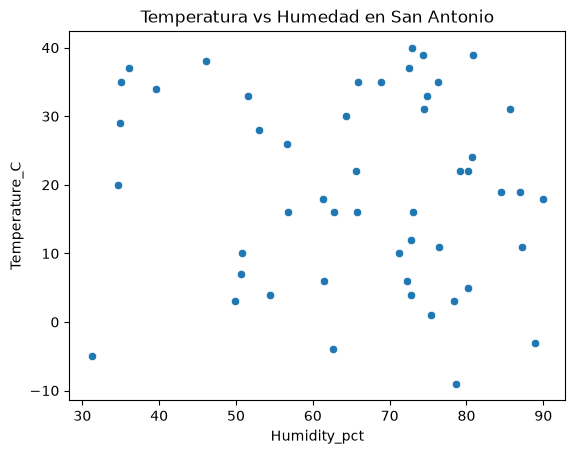

In [4]:
sns. scatterplot ( data = dfCiudad.head(50) , x="Humidity_pct", y="Temperature_C")
plt.title('Temperatura vs Humedad en San Antonio')
plt. show ()


### Gráfica 2: Temperatura a lo largo del tiempo en San Antonio

* **Tipo de Gráfica**: Gráfica de líneas (*Line plot*).
* **Variables analizadas**: Fecha y hora en el eje X con formato detallado (año-mes-día horas-minutos-segundos) y Temperatura (°C) en el eje Y. Solamente de los primeros 50 registros.
* **Visualización**: Una línea continua que zigzaguea constantemente conectando los puntos de temperatura a lo largo de la fecha y hora.
* **Observado**: La línea sube y baja de manera abrupta entre cada registro consecutivo sin seguir un orden fijo o suave.
* **Hipótesis**: La temperatura cambia drásticamente y de forma muy variada de un momento a otro en periodos cortos.
* **Interpretación**: No se puede asumir un cambio gradual o predecible de la temperatura a corto plazo, lo que indica alta volatilidad en los registros temporales.

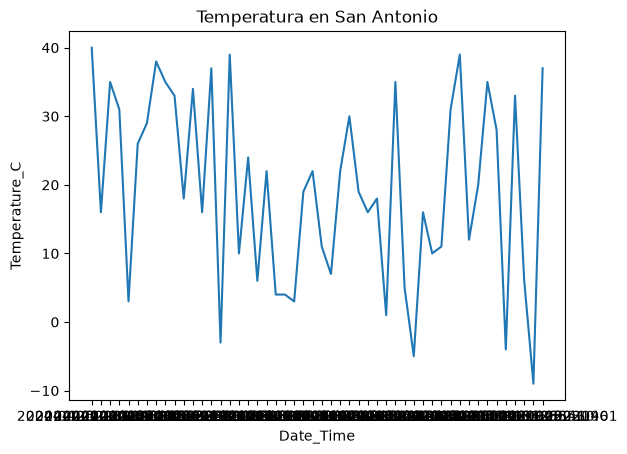

In [5]:
sns. lineplot ( data = dfCiudad.head(50) , x="Date_Time", y="Temperature_C", markers='o')
plt.title('Temperatura en San Antonio')
plt. show ()

### Gráfica 3: Distribución de la humedad en San Antonio

* **Tipo de Gráfica**: Diagrama de caja (*Boxplot*).
* **Variables analizadas**: Humedad en porcentaje en el eje Y. Solamente los primeros 50 registros.
* **Visualización**: Una caja rectangular con líneas verticales (bigotes) que representan los rangos y cuartiles de la humedad.
* **Observado**: El 50% central de la humedad se concentra principalmente entre el 55% y el 78%, con una línea media cerca del 72%, mientras que los bigotes muestran extremos que van desde un 31% hasta el 90%.
* **Hipótesis**: La mayor parte del tiempo el ambiente se mantiene con niveles de humedad moderados a altos, teniendo pocos registros en zonas muy secas o extremadamente húmedas.
* **Interpretación**: Al haber una concentración alta hacia los valores superiores, se puede esperar que predominen los ambientes húmedos en el periodo analizado, útil para planear alertas de clima seco.

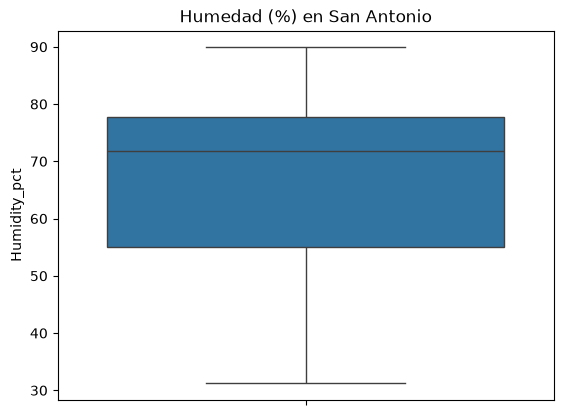

In [6]:
sns. boxplot ( data = dfCiudad.head(50) , y="Humidity_pct")
plt.title('Humedad (%) en San Antonio')
plt. show ()

### Gráfica 4: Máximos vientos registrados en 5 ciudades

* **Tipo de Gráfica**: Gráfica de barras (*Bar chart*).
* **Variables analizadas**: Ciudades (San Diego, New York, Houston, Dallas, Los Angeles) en el eje X y valores de velocidad máxima de viento en el eje Y.
* **Visualización**: Un diagrama de barras verticales que compara la velocidad máxima del viento entre las cinco ciudades.
* **Observado**: Dallas y New York alcanzan los niveles más altos (cerca de 89.909), mientras que Los Ángeles registra el valor más bajo (alrededor de 89.908).
* **Hipótesis**: Las ciudades del este y centro (como Dallas y Nueva York) presentan vientos máximos ligeramente superiores en este conjunto de datos frente a las de la costa oeste.
* **Interpretación**: Permite identificar qué ciudades concentran las mayores intensidades de viento para priorizar medidas de prevención o estudios de ráfagas extremas.

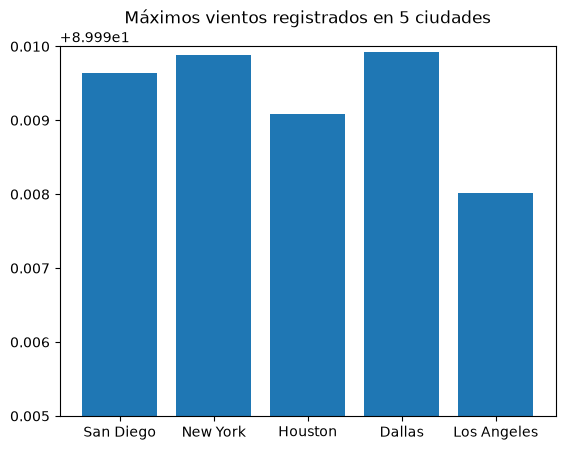

In [7]:
plt.bar(ciudades, valores)
plt.ylim(89.995, 90)
plt.title("Máximos vientos registrados en 5 ciudades")
plt.show()